In [ ]:
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl  # needed for reading Excel files (.xlsx)

import sklearn
from sklearn.svm import SVC
from sklearn.metrics import (
    balanced_accuracy_score, roc_auc_score, accuracy_score,
    confusion_matrix, roc_curve
)
from scipy.stats import zscore, pearsonr, uniform
from sklearn.linear_model import Ridge
from sklearn.model_selection import (
    KFold, StratifiedKFold, RandomizedSearchCV, train_test_split
)
from sklearn.preprocessing import StandardScaler
from scipy.io import loadmat

warnings.filterwarnings("ignore")
np.random.seed(42)

print("✅ Environment check:")
print(f"Python       : {sys.version.split()[0]}")
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"SciPy        : {__import__('scipy').__version__}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"Matplotlib   : {plt.matplotlib.__version__}")
print(f"Seaborn      : {sns.__version__}")
print(f"openpyxl     : {openpyxl.__version__}")

✅ Environment check:
Python       : 3.12.11
NumPy        : 2.0.2
Pandas       : 2.2.2
SciPy        : 1.16.2
scikit-learn : 1.6.1
Matplotlib   : 3.10.0
Seaborn      : 0.13.2
openpyxl     : 3.1.5


In [ ]:
train_cate = pd.read_excel("TRAIN_CATEGORICAL_METADATA.xlsx")
train_quant = pd.read_excel("TRAIN_QUANTITATIVE_METADATA.xlsx")
output_data = pd.read_excel("TRAINING_SOLUTIONS.xlsx")

In [ ]:
train_cate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   participant_id                    916 non-null    object 
 1   Basic_Demos_Enroll_Year           916 non-null    int64  
 2   Basic_Demos_Study_Site            916 non-null    int64  
 3   PreInt_Demos_Fam_Child_Ethnicity  879 non-null    float64
 4   PreInt_Demos_Fam_Child_Race       873 non-null    float64
 5   MRI_Track_Scan_Location           914 non-null    float64
 6   Barratt_Barratt_P1_Edu            904 non-null    float64
 7   Barratt_Barratt_P1_Occ            892 non-null    float64
 8   Barratt_Barratt_P2_Edu            778 non-null    float64
 9   Barratt_Barratt_P2_Occ            764 non-null    float64
dtypes: float64(7), int64(2), object(1)
memory usage: 71.7+ KB


In [ ]:
train_quant.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   participant_id              916 non-null    object 
 1   EHQ_EHQ_Total               909 non-null    float64
 2   ColorVision_CV_Score        900 non-null    float64
 3   APQ_P_APQ_P_CP              908 non-null    float64
 4   APQ_P_APQ_P_ID              908 non-null    float64
 5   APQ_P_APQ_P_INV             908 non-null    float64
 6   APQ_P_APQ_P_OPD             908 non-null    float64
 7   APQ_P_APQ_P_PM              908 non-null    float64
 8   APQ_P_APQ_P_PP              908 non-null    float64
 9   SDQ_SDQ_Conduct_Problems    911 non-null    float64
 10  SDQ_SDQ_Difficulties_Total  911 non-null    float64
 11  SDQ_SDQ_Emotional_Problems  911 non-null    float64
 12  SDQ_SDQ_Externalizing       911 non-null    float64
 13  SDQ_SDQ_Generating_Impact   911 non

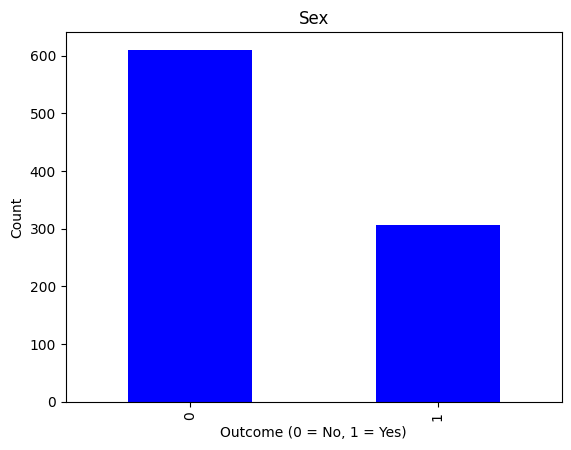

In [ ]:
output_data['Sex_F'].value_counts().plot(kind='bar', color='blue')
plt.title('Sex')
plt.xlabel('Outcome (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

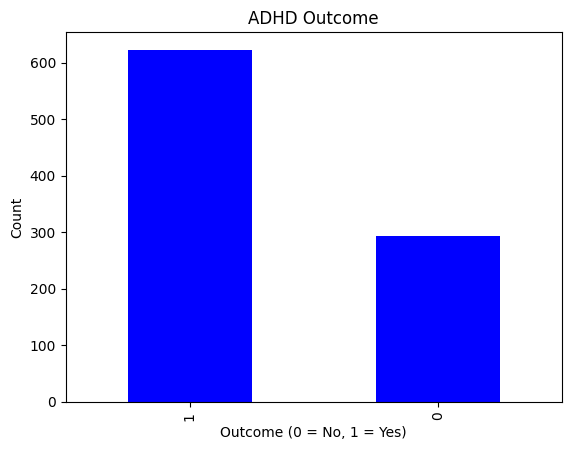

In [ ]:
output_data['ADHD_Outcome'].value_counts().plot(kind='bar', color='blue')
plt.title('ADHD Outcome')
plt.xlabel('Outcome (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

ENCODING CATEGORICAL DATASET

In [ ]:
for col in train_cate.select_dtypes(include=['int',"float64"]).columns:
    train_cate[col] = train_cate[col].astype('category')

In [ ]:
train_cate.dtypes

,0
participant_id,object
Basic_Demos_Enroll_Year,category
Basic_Demos_Study_Site,category
PreInt_Demos_Fam_Child_Ethnicity,category
PreInt_Demos_Fam_Child_Race,category
MRI_Track_Scan_Location,category
Barratt_Barratt_P1_Edu,category
Barratt_Barratt_P1_Occ,category
Barratt_Barratt_P2_Edu,category
Barratt_Barratt_P2_Occ,category


In [ ]:
# Creating a list of all of the columns except the first
columns_to_encode = train_cate.columns[1:].tolist()

# Print the columns to encode
print("Columns to encode:", columns_to_encode)

Columns to encode: ['Basic_Demos_Enroll_Year', 'Basic_Demos_Study_Site', 'PreInt_Demos_Fam_Child_Ethnicity', 'PreInt_Demos_Fam_Child_Race', 'MRI_Track_Scan_Location', 'Barratt_Barratt_P1_Edu', 'Barratt_Barratt_P1_Occ', 'Barratt_Barratt_P2_Edu', 'Barratt_Barratt_P2_Occ']


In [ ]:
train_encoded = pd.get_dummies(train_cate[columns_to_encode], drop_first=True)
train_encoded = train_encoded.applymap(lambda x: 1 if x is True else (0 if x is False else x))

In [ ]:
cat_train_final = pd.concat([train_cate.drop(columns=columns_to_encode), train_encoded], axis=1)

# ensure it looks correct
cat_train_final.columns

Index(['participant_id', 'Basic_Demos_Enroll_Year_2016',
       'Basic_Demos_Enroll_Year_2017', 'Basic_Demos_Enroll_Year_2018',
       'Basic_Demos_Enroll_Year_2019', 'Basic_Demos_Enroll_Year_2020',
       'Basic_Demos_Study_Site_2', 'Basic_Demos_Study_Site_3',
       'Basic_Demos_Study_Site_4', 'PreInt_Demos_Fam_Child_Ethnicity_1.0',
       'PreInt_Demos_Fam_Child_Ethnicity_2.0',
       'PreInt_Demos_Fam_Child_Ethnicity_3.0',
       'PreInt_Demos_Fam_Child_Race_1.0', 'PreInt_Demos_Fam_Child_Race_2.0',
       'PreInt_Demos_Fam_Child_Race_3.0', 'PreInt_Demos_Fam_Child_Race_4.0',
       'PreInt_Demos_Fam_Child_Race_7.0', 'PreInt_Demos_Fam_Child_Race_8.0',
       'PreInt_Demos_Fam_Child_Race_9.0', 'PreInt_Demos_Fam_Child_Race_10.0',
       'PreInt_Demos_Fam_Child_Race_11.0', 'MRI_Track_Scan_Location_2.0',
       'MRI_Track_Scan_Location_3.0', 'MRI_Track_Scan_Location_4.0',
       'Barratt_Barratt_P1_Edu_6.0', 'Barratt_Barratt_P1_Edu_9.0',
       'Barratt_Barratt_P1_Edu_12.0', 'Barratt_Bar

# MERGE WITH OUTPUT

In [ ]:
train_cate_quant = pd.merge(train_quant, cat_train_final, left_on=cat_train_final.columns[0], right_on=train_quant.columns[0], how="inner")
train_cate_quant.columns

Index(['participant_id', 'EHQ_EHQ_Total', 'ColorVision_CV_Score',
       'APQ_P_APQ_P_CP', 'APQ_P_APQ_P_ID', 'APQ_P_APQ_P_INV',
       'APQ_P_APQ_P_OPD', 'APQ_P_APQ_P_PM', 'APQ_P_APQ_P_PP',
       'SDQ_SDQ_Conduct_Problems', 'SDQ_SDQ_Difficulties_Total',
       'SDQ_SDQ_Emotional_Problems', 'SDQ_SDQ_Externalizing',
       'SDQ_SDQ_Generating_Impact', 'SDQ_SDQ_Hyperactivity',
       'SDQ_SDQ_Internalizing', 'SDQ_SDQ_Peer_Problems', 'SDQ_SDQ_Prosocial',
       'MRI_Track_Age_at_Scan', 'Basic_Demos_Enroll_Year_2016',
       'Basic_Demos_Enroll_Year_2017', 'Basic_Demos_Enroll_Year_2018',
       'Basic_Demos_Enroll_Year_2019', 'Basic_Demos_Enroll_Year_2020',
       'Basic_Demos_Study_Site_2', 'Basic_Demos_Study_Site_3',
       'Basic_Demos_Study_Site_4', 'PreInt_Demos_Fam_Child_Ethnicity_1.0',
       'PreInt_Demos_Fam_Child_Ethnicity_2.0',
       'PreInt_Demos_Fam_Child_Ethnicity_3.0',
       'PreInt_Demos_Fam_Child_Race_1.0', 'PreInt_Demos_Fam_Child_Race_2.0',
       'PreInt_Demos_Fam_Chil

In [ ]:
train_data = pd.merge(train_cate_quant, output_data, left_on=cat_train_final.columns[0], right_on=output_data.columns[0], how="inner")
train_data.columns

Index(['participant_id', 'EHQ_EHQ_Total', 'ColorVision_CV_Score',
       'APQ_P_APQ_P_CP', 'APQ_P_APQ_P_ID', 'APQ_P_APQ_P_INV',
       'APQ_P_APQ_P_OPD', 'APQ_P_APQ_P_PM', 'APQ_P_APQ_P_PP',
       'SDQ_SDQ_Conduct_Problems', 'SDQ_SDQ_Difficulties_Total',
       'SDQ_SDQ_Emotional_Problems', 'SDQ_SDQ_Externalizing',
       'SDQ_SDQ_Generating_Impact', 'SDQ_SDQ_Hyperactivity',
       'SDQ_SDQ_Internalizing', 'SDQ_SDQ_Peer_Problems', 'SDQ_SDQ_Prosocial',
       'MRI_Track_Age_at_Scan', 'Basic_Demos_Enroll_Year_2016',
       'Basic_Demos_Enroll_Year_2017', 'Basic_Demos_Enroll_Year_2018',
       'Basic_Demos_Enroll_Year_2019', 'Basic_Demos_Enroll_Year_2020',
       'Basic_Demos_Study_Site_2', 'Basic_Demos_Study_Site_3',
       'Basic_Demos_Study_Site_4', 'PreInt_Demos_Fam_Child_Ethnicity_1.0',
       'PreInt_Demos_Fam_Child_Ethnicity_2.0',
       'PreInt_Demos_Fam_Child_Ethnicity_3.0',
       'PreInt_Demos_Fam_Child_Race_1.0', 'PreInt_Demos_Fam_Child_Race_2.0',
       'PreInt_Demos_Fam_Chil

In [ ]:
train_data.head()

,participant_id,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,...,Barratt_Barratt_P2_Occ_10.0,Barratt_Barratt_P2_Occ_15.0,Barratt_Barratt_P2_Occ_20.0,Barratt_Barratt_P2_Occ_25.0,Barratt_Barratt_P2_Occ_30.0,Barratt_Barratt_P2_Occ_35.0,Barratt_Barratt_P2_Occ_40.0,Barratt_Barratt_P2_Occ_45.0,ADHD_Outcome,Sex_F
0,P00001,100.00,13.0,3.0,15.0,44.0,14.0,20.0,27.0,3.0,...,0,0,0,0,0,0,0,0,1,0
1,P00003,86.67,14.0,3.0,21.0,37.0,18.0,26.0,28.0,3.0,...,0,0,0,0,0,0,0,0,0,1
2,P00004,93.34,14.0,3.0,11.0,42.0,15.0,20.0,28.0,0.0,...,0,0,0,0,0,0,0,0,0,1
3,P00006,-100.00,14.0,5.0,16.0,36.0,19.0,13.0,22.0,6.0,...,0,0,0,0,0,0,1,0,1,0
4,P00007,100.00,14.0,4.0,13.0,34.0,16.0,13.0,21.0,1.0,...,0,0,0,0,1,0,0,0,1,0


# MISSING VALUE
Numeric columns → fill NaNs with the column mean.
Categorical columns → fill NaNs with the most frequent value (mode).

In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 74 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   participant_id                        916 non-null    object 
 1   EHQ_EHQ_Total                         909 non-null    float64
 2   ColorVision_CV_Score                  900 non-null    float64
 3   APQ_P_APQ_P_CP                        908 non-null    float64
 4   APQ_P_APQ_P_ID                        908 non-null    float64
 5   APQ_P_APQ_P_INV                       908 non-null    float64
 6   APQ_P_APQ_P_OPD                       908 non-null    float64
 7   APQ_P_APQ_P_PM                        908 non-null    float64
 8   APQ_P_APQ_P_PP                        908 non-null    float64
 9   SDQ_SDQ_Conduct_Problems              911 non-null    float64
 10  SDQ_SDQ_Difficulties_Total            911 non-null    float64
 11  SDQ_SDQ_Emotional_P

In [ ]:
# Check if there are any NaNs in the features
print("Total NaNs in train_df:", train_data.isna().sum().sum())

# Percentage of NaNs per column (top 15)
nan_report = train_data.isna().mean().sort_values(ascending=False) * 100
print("Top columns with missing values (%):")
display(nan_report.head(15))

Total NaNs in train_df: 390
Top columns with missing values (%):


,0
MRI_Track_Age_at_Scan,29.912664
ColorVision_CV_Score,1.746725
APQ_P_APQ_P_OPD,0.873362
APQ_P_APQ_P_PM,0.873362
APQ_P_APQ_P_ID,0.873362
APQ_P_APQ_P_INV,0.873362
APQ_P_APQ_P_PP,0.873362
APQ_P_APQ_P_CP,0.873362
EHQ_EHQ_Total,0.764192
SDQ_SDQ_Conduct_Problems,0.545852


In [ ]:
train_data_nan = train_data.copy()

In [ ]:
id_col = "participant_id"

# Fill numeric columns with column mean, categorical with mode
for c in train_data.columns:
    if c == id_col:
        continue
    if pd.api.types.is_numeric_dtype(train_data[c]):
        train_data[c] = train_data[c].fillna(train_data[c].mean())
    else:
        train_data[c] = train_data[c].fillna(train_data[c].mode().iloc[0])

print("NaNs filled: numeric -> mean, categorical -> mode")

NaNs filled: numeric -> mean, categorical -> mode


In [ ]:
train_data_nan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 74 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   participant_id                        916 non-null    object 
 1   EHQ_EHQ_Total                         909 non-null    float64
 2   ColorVision_CV_Score                  900 non-null    float64
 3   APQ_P_APQ_P_CP                        908 non-null    float64
 4   APQ_P_APQ_P_ID                        908 non-null    float64
 5   APQ_P_APQ_P_INV                       908 non-null    float64
 6   APQ_P_APQ_P_OPD                       908 non-null    float64
 7   APQ_P_APQ_P_PM                        908 non-null    float64
 8   APQ_P_APQ_P_PP                        908 non-null    float64
 9   SDQ_SDQ_Conduct_Problems              911 non-null    float64
 10  SDQ_SDQ_Difficulties_Total            911 non-null    float64
 11  SDQ_SDQ_Emotional_P

In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 74 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   participant_id                        916 non-null    object 
 1   EHQ_EHQ_Total                         916 non-null    float64
 2   ColorVision_CV_Score                  916 non-null    float64
 3   APQ_P_APQ_P_CP                        916 non-null    float64
 4   APQ_P_APQ_P_ID                        916 non-null    float64
 5   APQ_P_APQ_P_INV                       916 non-null    float64
 6   APQ_P_APQ_P_OPD                       916 non-null    float64
 7   APQ_P_APQ_P_PM                        916 non-null    float64
 8   APQ_P_APQ_P_PP                        916 non-null    float64
 9   SDQ_SDQ_Conduct_Problems              916 non-null    float64
 10  SDQ_SDQ_Difficulties_Total            916 non-null    float64
 11  SDQ_SDQ_Emotional_P

# DEAL WITH IMBALANCES

In [ ]:
# gender oversampling
from sklearn.datasets import make_classification
from imblearn.over_sampling import RandomOverSampler
X = train_data.drop('Sex_F', axis=1)
y = train_data['Sex_F']

gender_oversampler = RandomOverSampler(sampling_strategy='auto', random_state=42)
X_resampled_gender, y_resampled_gender = gender_oversampler.fit_resample(X, y)

In [ ]:
# ADHD oversampling
from sklearn.datasets import make_classification
from imblearn.over_sampling import RandomOverSampler
X = train_data.drop('ADHD_Outcome', axis=1)
y = train_data['ADHD_Outcome']

adhd_oversampler = RandomOverSampler(sampling_strategy='auto', random_state=42)
X_resampled_adhd, y_resampled_adhd = adhd_oversampler.fit_resample(X, y)

In [ ]:
# ADHD
data_after_sampling_adhd = X_resampled_adhd.join(y_resampled_adhd)

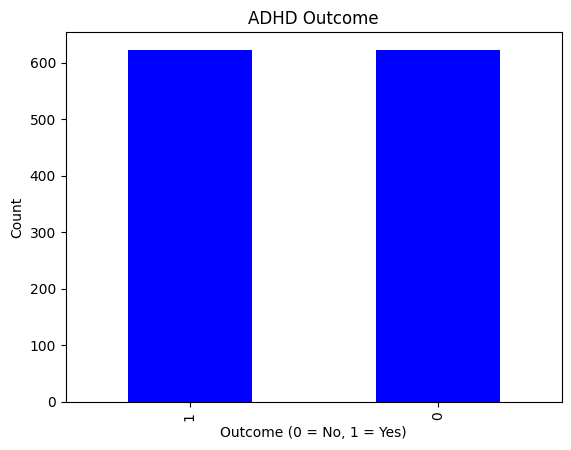

In [ ]:
# ADHD
data_after_sampling_adhd['ADHD_Outcome'].value_counts().plot(kind='bar', color='blue')
plt.title('ADHD Outcome')
plt.xlabel('Outcome (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

In [ ]:
# Gender
data_after_sampling_gender = X_resampled_gender.join(y_resampled_gender)

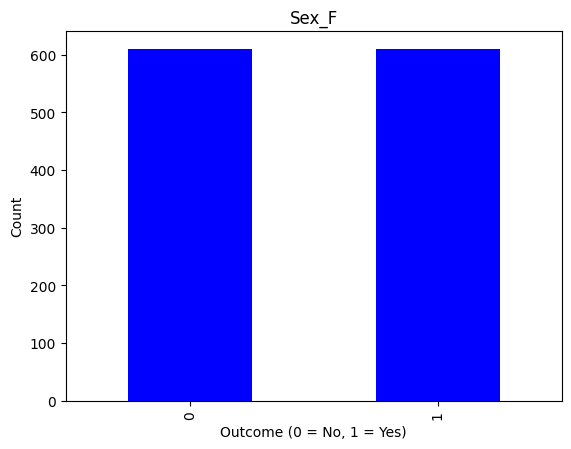

In [ ]:
# Gender
data_after_sampling_gender['Sex_F'].value_counts().plot(kind='bar', color='blue')
plt.title('Sex_F')
plt.xlabel('Outcome (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

# FEATURE SELECTION using XGBOOST


In [235]:
from xgboost import XGBClassifier

# Initialize the base classifier
xgb_classifier = XGBClassifier(objective='binary:logistic', n_estimators=100, learning_rate=0.1, max_depth=3)

In [236]:
X_train_gender1 = data_after_sampling_gender.drop(columns = ['participant_id', 'ADHD_Outcome', 'Sex_F'])
Y_train_gender1 = data_after_sampling_gender[['Sex_F']]

print("Shape of X_train:", X_train_gender1.shape)
print("Shape of Y_train:", Y_train_gender1.shape)

Shape of X_train: (1220, 71)
Shape of Y_train: (1220, 1)


In [273]:
X_train_gender1

,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,...,Barratt_Barratt_P2_Edu_21.0,Barratt_Barratt_P2_Occ_5.0,Barratt_Barratt_P2_Occ_10.0,Barratt_Barratt_P2_Occ_15.0,Barratt_Barratt_P2_Occ_20.0,Barratt_Barratt_P2_Occ_25.0,Barratt_Barratt_P2_Occ_30.0,Barratt_Barratt_P2_Occ_35.0,Barratt_Barratt_P2_Occ_40.0,Barratt_Barratt_P2_Occ_45.0
0,100.00,13.0,3.0,15.0,44.0,14.0,20.0,27.0,3.0,17.0,...,0,0,0,0,0,0,0,0,0,0
1,86.67,14.0,3.0,21.0,37.0,18.0,26.0,28.0,3.0,24.0,...,0,0,0,0,0,0,0,0,0,0
2,93.34,14.0,3.0,11.0,42.0,15.0,20.0,28.0,0.0,5.0,...,0,0,0,0,0,0,0,0,0,0
3,-100.00,14.0,5.0,16.0,36.0,19.0,13.0,22.0,6.0,22.0,...,0,0,0,0,0,0,0,0,1,0
4,100.00,14.0,4.0,13.0,34.0,16.0,13.0,21.0,1.0,8.0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1215,-66.67,14.0,5.0,12.0,37.0,16.0,10.0,28.0,1.0,19.0,...,0,0,0,0,1,0,0,0,0,0
1216,73.34,14.0,6.0,17.0,38.0,20.0,10.0,27.0,4.0,14.0,...,1,0,0,0,0,0,1,0,0,0
1217,73.34,14.0,4.0,16.0,30.0,15.0,25.0,22.0,2.0,16.0,...,0,0,0,0,0,0,0,0,0,0
1218,93.34,14.0,5.0,12.0,37.0,19.0,18.0,24.0,4.0,12.0,...,0,0,0,0,0,1,0,0,0,0


In [237]:
# Train the model
xgb_classifier.fit(X_train_gender1, Y_train_gender1)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

  Feature selection


In [238]:
import pandas as pd
from numpy import sort
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split
#from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score

In [240]:
X_train2_gender, X_test2_gender, y_train2_gender, y_test2_gender = train_test_split(X_train_gender1, Y_train_gender1, test_size=0.3, random_state=42)

In [241]:
X_train2_gender.shape

(854, 71)

In [242]:
y_train2_gender.shape

(854, 1)

In [243]:
y_pred = xgb_classifier.predict(X_test2_gender)
f1_score_gender = f1_score(y_test2_gender, y_pred)

print(f"Accuracy: {f1_score_gender:.4f}")

Accuracy: 0.8794


In [244]:
thresholds = sort(xgb_classifier.feature_importances_)

In [245]:
for thresh in thresholds:
 # select features using threshold
 selection = SelectFromModel(xgb_classifier, threshold=thresh, prefit=True)
 selection_X_train = selection.transform(X_train2_gender)
 selection_X_test = selection.transform(X_test2_gender)
 # train model
 selection_model = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1)
 selection_model.fit(selection_X_train, y_train2_gender)
 # eval model
 predictions = selection_model.predict(selection_X_test)
 f1_score2_gender = f1_score(y_test2_gender, predictions)
 print("Thresh=%.3f, n=%d, F1_score: %.2f%%" % (thresh, X_train2_gender.shape[1], f1_score2_gender*100.0))

Thresh=0.000, n=71, F1_score: 70.24%
Thresh=0.000, n=71, F1_score: 70.24%
Thresh=0.000, n=71, F1_score: 70.24%
Thresh=0.000, n=71, F1_score: 70.24%
Thresh=0.000, n=71, F1_score: 70.24%
Thresh=0.000, n=71, F1_score: 70.24%
Thresh=0.000, n=71, F1_score: 70.24%
Thresh=0.000, n=71, F1_score: 70.24%
Thresh=0.000, n=71, F1_score: 70.24%
Thresh=0.000, n=71, F1_score: 70.24%
Thresh=0.000, n=71, F1_score: 70.24%
Thresh=0.000, n=71, F1_score: 70.24%
Thresh=0.000, n=71, F1_score: 70.24%
Thresh=0.000, n=71, F1_score: 70.24%
Thresh=0.000, n=71, F1_score: 70.24%
Thresh=0.000, n=71, F1_score: 70.24%
Thresh=0.000, n=71, F1_score: 70.24%
Thresh=0.000, n=71, F1_score: 70.24%
Thresh=0.000, n=71, F1_score: 70.24%
Thresh=0.000, n=71, F1_score: 70.24%
Thresh=0.000, n=71, F1_score: 70.24%
Thresh=0.000, n=71, F1_score: 70.24%
Thresh=0.000, n=71, F1_score: 70.24%
Thresh=0.000, n=71, F1_score: 70.24%
Thresh=0.003, n=71, F1_score: 68.87%
Thresh=0.009, n=71, F1_score: 70.11%
Thresh=0.010, n=71, F1_score: 70.11%
T

In [246]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, accuracy_score

In [247]:
from sklearn.model_selection import cross_val_score
cv_gender_xg = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_gender_xg = cross_val_score(xgb_classifier, X_train_gender1, Y_train_gender1, cv=cv_gender_rf, scoring='f1')
scores_gender_xg
print("Mean CV score:", np.mean(scores_gender_xg))

Mean CV score: 0.7161929970473067


# PREPARE FOR TEST DATA

In [ ]:
test_cate = pd.read_excel("TEST_CATEGORICAL.xlsx")
test_quant = pd.read_excel("TEST_QUANTITATIVE.xlsx")

In [ ]:
#encoding
for col in test_cate.select_dtypes(include=['int',"float64"]).columns:
    test_cate[col] = test_cate[col].astype('category')

In [ ]:
test_cate.dtypes

,0
participant_id,object
Basic_Demos_Enroll_Year,category
Basic_Demos_Study_Site,category
PreInt_Demos_Fam_Child_Ethnicity,category
PreInt_Demos_Fam_Child_Race,category
MRI_Track_Scan_Location,category
Barratt_Barratt_P1_Edu,category
Barratt_Barratt_P1_Occ,category
Barratt_Barratt_P2_Edu,category
Barratt_Barratt_P2_Occ,category


In [ ]:
# Creating a list of all of the columns except the first
columns_to_encode2 = test_cate.columns[1:].tolist()

# Print the columns to encode
print("Columns to encode:", columns_to_encode2)

Columns to encode: ['Basic_Demos_Enroll_Year', 'Basic_Demos_Study_Site', 'PreInt_Demos_Fam_Child_Ethnicity', 'PreInt_Demos_Fam_Child_Race', 'MRI_Track_Scan_Location', 'Barratt_Barratt_P1_Edu', 'Barratt_Barratt_P1_Occ', 'Barratt_Barratt_P2_Edu', 'Barratt_Barratt_P2_Occ']


In [ ]:
test_encoded = pd.get_dummies(test_cate[columns_to_encode2], drop_first=True)
test_encoded = test_encoded.applymap(lambda x: 1 if x is True else (0 if x is False else x))

In [ ]:
cat_test_final = pd.concat([test_cate.drop(columns=columns_to_encode2), test_encoded], axis=1)

# ensure it looks correct
cat_test_final.head()

,participant_id,Basic_Demos_Enroll_Year_2016,Basic_Demos_Enroll_Year_2017,Basic_Demos_Enroll_Year_2018,Basic_Demos_Enroll_Year_2019,Basic_Demos_Enroll_Year_2020,Basic_Demos_Study_Site_2,Basic_Demos_Study_Site_3,Basic_Demos_Study_Site_4,PreInt_Demos_Fam_Child_Ethnicity_1.0,...,Barratt_Barratt_P2_Edu_21.0,Barratt_Barratt_P2_Occ_5.0,Barratt_Barratt_P2_Occ_10.0,Barratt_Barratt_P2_Occ_15.0,Barratt_Barratt_P2_Occ_20.0,Barratt_Barratt_P2_Occ_25.0,Barratt_Barratt_P2_Occ_30.0,Barratt_Barratt_P2_Occ_35.0,Barratt_Barratt_P2_Occ_40.0,Barratt_Barratt_P2_Occ_45.0
0,P00002,0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
1,P00005,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,P00010,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,P00013,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,P00016,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
test_data = pd.merge(test_quant, cat_test_final, left_on=cat_test_final.columns[0], right_on=test_quant.columns[0], how="inner")

In [ ]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382 entries, 0 to 381
Data columns (total 71 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   participant_id                        382 non-null    object 
 1   EHQ_EHQ_Total                         376 non-null    float64
 2   ColorVision_CV_Score                  374 non-null    float64
 3   APQ_P_APQ_P_CP                        377 non-null    float64
 4   APQ_P_APQ_P_ID                        377 non-null    float64
 5   APQ_P_APQ_P_INV                       377 non-null    float64
 6   APQ_P_APQ_P_OPD                       377 non-null    float64
 7   APQ_P_APQ_P_PM                        377 non-null    float64
 8   APQ_P_APQ_P_PP                        377 non-null    float64
 9   SDQ_SDQ_Conduct_Problems              376 non-null    float64
 10  SDQ_SDQ_Difficulties_Total            376 non-null    float64
 11  SDQ_SDQ_Emotional_P

In [ ]:
test_data_nan = test_data.copy()

In [ ]:
id_col = "participant_id"

# Fill numeric columns with column mean, categorical with mode
for c in test_data.columns:
    if c == id_col:
        continue
    if pd.api.types.is_numeric_dtype(test_data[c]):
        test_data[c] = test_data[c].fillna(test_data[c].mean())
    else:
        test_data[c] = test_data[c].fillna(test_data[c].mode().iloc[0])

print("NaNs filled: numeric -> mean, categorical -> mode")

NaNs filled: numeric -> mean, categorical -> mode


In [ ]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382 entries, 0 to 381
Data columns (total 71 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   participant_id                        382 non-null    object 
 1   EHQ_EHQ_Total                         382 non-null    float64
 2   ColorVision_CV_Score                  382 non-null    float64
 3   APQ_P_APQ_P_CP                        382 non-null    float64
 4   APQ_P_APQ_P_ID                        382 non-null    float64
 5   APQ_P_APQ_P_INV                       382 non-null    float64
 6   APQ_P_APQ_P_OPD                       382 non-null    float64
 7   APQ_P_APQ_P_PM                        382 non-null    float64
 8   APQ_P_APQ_P_PP                        382 non-null    float64
 9   SDQ_SDQ_Conduct_Problems              382 non-null    float64
 10  SDQ_SDQ_Difficulties_Total            382 non-null    float64
 11  SDQ_SDQ_Emotional_P

# FEATURE SELECTION WITH RANDOM FOREST

For Sex data

In [ ]:
data_after_sampling_gender.columns

Index(['participant_id', 'EHQ_EHQ_Total', 'ColorVision_CV_Score',
       'APQ_P_APQ_P_CP', 'APQ_P_APQ_P_ID', 'APQ_P_APQ_P_INV',
       'APQ_P_APQ_P_OPD', 'APQ_P_APQ_P_PM', 'APQ_P_APQ_P_PP',
       'SDQ_SDQ_Conduct_Problems', 'SDQ_SDQ_Difficulties_Total',
       'SDQ_SDQ_Emotional_Problems', 'SDQ_SDQ_Externalizing',
       'SDQ_SDQ_Generating_Impact', 'SDQ_SDQ_Hyperactivity',
       'SDQ_SDQ_Internalizing', 'SDQ_SDQ_Peer_Problems', 'SDQ_SDQ_Prosocial',
       'MRI_Track_Age_at_Scan', 'Basic_Demos_Enroll_Year_2016',
       'Basic_Demos_Enroll_Year_2017', 'Basic_Demos_Enroll_Year_2018',
       'Basic_Demos_Enroll_Year_2019', 'Basic_Demos_Enroll_Year_2020',
       'Basic_Demos_Study_Site_2', 'Basic_Demos_Study_Site_3',
       'Basic_Demos_Study_Site_4', 'PreInt_Demos_Fam_Child_Ethnicity_1.0',
       'PreInt_Demos_Fam_Child_Ethnicity_2.0',
       'PreInt_Demos_Fam_Child_Ethnicity_3.0',
       'PreInt_Demos_Fam_Child_Race_1.0', 'PreInt_Demos_Fam_Child_Race_2.0',
       'PreInt_Demos_Fam_Chil

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train_gender_rf = data_after_sampling_gender.drop(columns=["Sex_F", "participant_id"])
y_train_gender_rf = data_after_sampling_gender["Sex_F"]


rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_gender_rf, y_train_gender_rf)

RandomForestClassifier(random_state=42)

In [ ]:
import matplotlib.pyplot as plt

# Get feature importance
feature_importances = pd.DataFrame({
    'feature': X_train_gender_rf.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feature_importances.head(10))

                  feature  importance
17  MRI_Track_Age_at_Scan    0.057267
4         APQ_P_APQ_P_INV    0.049212
3          APQ_P_APQ_P_ID    0.047340
6          APQ_P_APQ_P_PM    0.046833
0           EHQ_EHQ_Total    0.044551
5         APQ_P_APQ_P_OPD    0.043975
13  SDQ_SDQ_Hyperactivity    0.043631
16      SDQ_SDQ_Prosocial    0.043252
14  SDQ_SDQ_Internalizing    0.043217
11  SDQ_SDQ_Externalizing    0.041237


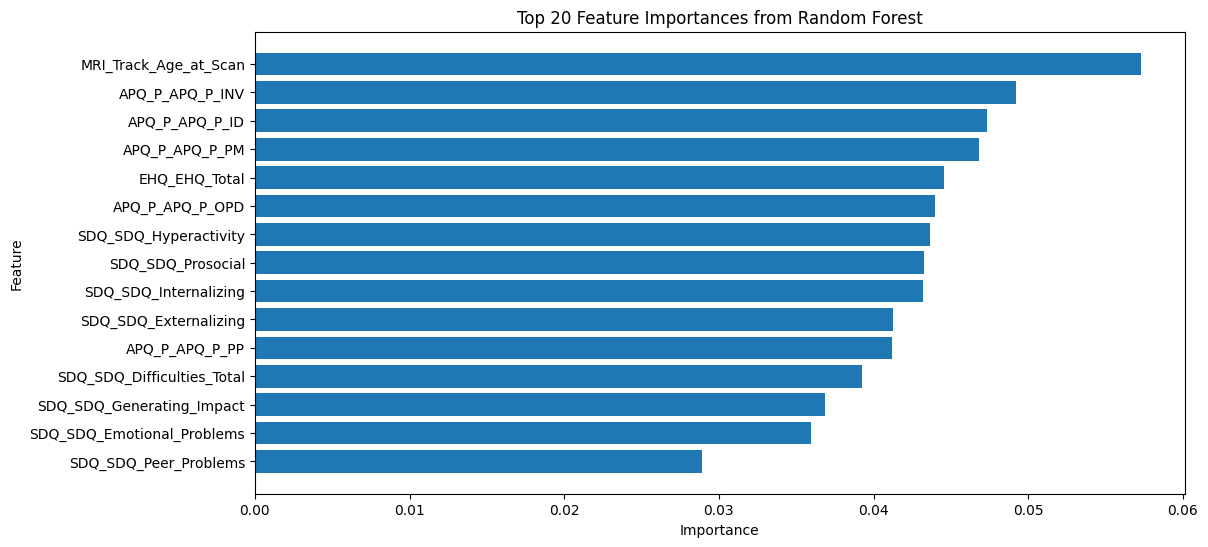

In [ ]:
plt.figure(figsize=(12,6))
plt.barh(feature_importances['feature'].head(15), feature_importances['importance'].head(15))
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances from Random Forest")
plt.gca().invert_yaxis()  # largest on top
plt.show()

In [ ]:
top_features = feature_importances['feature'].head(10).tolist()
X_train_top = X_train_gender_rf[top_features]
X_test_top = test_data[top_features]

#train a new model with only top features
rf_top = RandomForestClassifier(n_estimators=100, random_state=42)
rf_top.fit(X_train_top, y_train_gender_rf)

RandomForestClassifier(random_state=42)

prediction result

In [ ]:
y_pred_sampling_gender = rf.predict(X_train_gender_rf)
pred_y_pred_sampling_gender = pd.DataFrame(y_pred_sampling_gender, columns=["Predicted classes"])
pred_y_pred_sampling_gender["actual value"] = y_train_gender_rf
pred_y_pred_sampling_gender

,Predicted classes,actual value
0,0,0
1,1,1
2,1,1
3,0,0
4,0,0
...,...,...
1215,1,1
1216,1,1
1217,1,1
1218,1,1


Cross validation

In [ ]:
from sklearn.model_selection import cross_val_score
cv_gender_rf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_gender_rf = cross_val_score(rf, X_train_top, y_train_gender_rf, cv=cv_gender_rf, scoring='f1')
scores_gender_rf
print("Mean CV score:", np.mean(scores_gender_rf))

Mean CV score: 0.8292097197014124


For ADHD data

In [ ]:
data_after_sampling_adhd.columns

Index(['participant_id', 'EHQ_EHQ_Total', 'ColorVision_CV_Score',
       'APQ_P_APQ_P_CP', 'APQ_P_APQ_P_ID', 'APQ_P_APQ_P_INV',
       'APQ_P_APQ_P_OPD', 'APQ_P_APQ_P_PM', 'APQ_P_APQ_P_PP',
       'SDQ_SDQ_Conduct_Problems', 'SDQ_SDQ_Difficulties_Total',
       'SDQ_SDQ_Emotional_Problems', 'SDQ_SDQ_Externalizing',
       'SDQ_SDQ_Generating_Impact', 'SDQ_SDQ_Hyperactivity',
       'SDQ_SDQ_Internalizing', 'SDQ_SDQ_Peer_Problems', 'SDQ_SDQ_Prosocial',
       'MRI_Track_Age_at_Scan', 'Basic_Demos_Enroll_Year_2016',
       'Basic_Demos_Enroll_Year_2017', 'Basic_Demos_Enroll_Year_2018',
       'Basic_Demos_Enroll_Year_2019', 'Basic_Demos_Enroll_Year_2020',
       'Basic_Demos_Study_Site_2', 'Basic_Demos_Study_Site_3',
       'Basic_Demos_Study_Site_4', 'PreInt_Demos_Fam_Child_Ethnicity_1.0',
       'PreInt_Demos_Fam_Child_Ethnicity_2.0',
       'PreInt_Demos_Fam_Child_Ethnicity_3.0',
       'PreInt_Demos_Fam_Child_Race_1.0', 'PreInt_Demos_Fam_Child_Race_2.0',
       'PreInt_Demos_Fam_Chil

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train_adhd_rf = data_after_sampling_gender.drop(columns=["ADHD_Outcome", "participant_id"])
y_train_adhd_rf = data_after_sampling_gender["ADHD_Outcome"]


rf_adhd = RandomForestClassifier(n_estimators=100, random_state=42)
rf_adhd.fit(X_train_adhd_rf, y_train_adhd_rf)

RandomForestClassifier(random_state=42)

In [ ]:
#Get feature importance
feature_importances_adhd = pd.DataFrame({
    'feature': X_train_adhd_rf.columns,
    'importance': rf_adhd.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feature_importances_adhd.head(10))

                       feature  importance
13       SDQ_SDQ_Hyperactivity    0.116702
11       SDQ_SDQ_Externalizing    0.101326
9   SDQ_SDQ_Difficulties_Total    0.085112
12   SDQ_SDQ_Generating_Impact    0.070049
5              APQ_P_APQ_P_OPD    0.040354
17       MRI_Track_Age_at_Scan    0.039918
4              APQ_P_APQ_P_INV    0.036148
3               APQ_P_APQ_P_ID    0.033316
14       SDQ_SDQ_Internalizing    0.033095
6               APQ_P_APQ_P_PM    0.032531


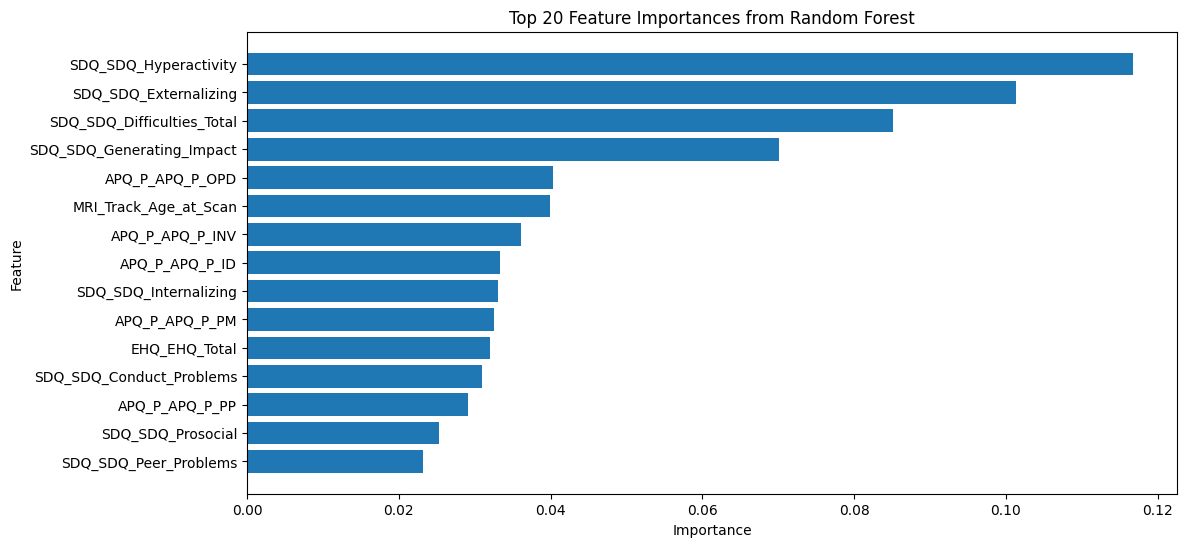

In [ ]:
plt.figure(figsize=(12,6))
plt.barh(feature_importances_adhd['feature'].head(15), feature_importances_adhd['importance'].head(15))
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances from Random Forest")
plt.gca().invert_yaxis()  # largest on top
plt.show()

In [ ]:
top_features_adhd = feature_importances_adhd['feature'].head(10).tolist()
X_train_top_adhd = X_train_adhd_rf[top_features_adhd]
X_test_top_adhd = test_data[top_features_adhd]

#train a new model with only top features
rf_top_adhd = RandomForestClassifier(n_estimators=100, random_state=42)
rf_top_adhd.fit(X_train_top_adhd, y_train_adhd_rf)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_sampling_adhd = rf_adhd.predict(X_train_adhd_rf)
pred_y_pred_sampling_adhd = pd.DataFrame(y_pred_sampling_adhd, columns=["Predicted classes"])
pred_y_pred_sampling_adhd["actual value"] = y_train_adhd_rf
pred_y_pred_sampling_adhd

,Predicted classes,actual value
0,1,1
1,0,0
2,0,0
3,1,1
4,1,1
...,...,...
1215,1,1
1216,1,1
1217,0,0
1218,0,0


In [ ]:
from sklearn.model_selection import cross_val_score
cv_adhd_rf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_adhd_rf = cross_val_score(rf, X_train_top_adhd, y_train_adhd_rf, cv=cv_adhd_rf, scoring='f1')
scores_adhd_rf
print("Mean CV score:", np.mean(scores_adhd_rf))

Mean CV score: 0.8939871093399034


# RESULT

In [260]:
test_data

,participant_id,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,...,Barratt_Barratt_P2_Edu_21.0,Barratt_Barratt_P2_Occ_5.0,Barratt_Barratt_P2_Occ_10.0,Barratt_Barratt_P2_Occ_15.0,Barratt_Barratt_P2_Occ_20.0,Barratt_Barratt_P2_Occ_25.0,Barratt_Barratt_P2_Occ_30.0,Barratt_Barratt_P2_Occ_35.0,Barratt_Barratt_P2_Occ_40.0,Barratt_Barratt_P2_Occ_45.0
0,P00002,92.270000,14.000000,3.000000,12.000000,35.000000,25.000000,28.000000,30.000000,5.000000,...,1,0,0,0,0,0,0,0,0,1
1,P00005,0.000000,14.000000,8.000000,12.000000,35.000000,22.000000,12.000000,24.000000,6.000000,...,0,0,0,0,0,0,0,0,0,0
2,P00010,86.670000,14.000000,3.000000,14.000000,46.000000,16.000000,10.000000,26.000000,3.000000,...,0,0,0,0,0,0,0,0,0,0
3,P00013,-23.330000,14.000000,3.000000,9.000000,48.000000,19.000000,21.000000,27.000000,0.000000,...,0,0,0,0,0,0,0,0,1,0
4,P00016,93.340000,14.000000,3.000000,13.000000,47.000000,16.000000,14.000000,29.000000,1.000000,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377,S036330777088,94.667705,14.022653,3.101029,7.759739,43.416868,12.040338,14.225668,28.033420,0.235625,...,0,0,0,0,0,0,0,0,0,0
378,S164740904116,-56.407806,13.908514,4.799993,13.377281,40.112110,19.378968,15.281948,17.864964,2.802046,...,0,0,0,0,0,0,0,1,0,0
379,S439759498192,90.229624,13.993993,4.900785,11.823732,45.340636,16.970138,9.311756,27.724899,0.775710,...,0,0,0,0,0,0,0,0,1,0
380,S373637088515,98.609533,14.108959,2.854294,9.011226,40.155713,22.647078,10.497790,28.728910,0.777260,...,1,0,0,0,0,0,0,1,0,0


In [266]:
y_adhd = rf_top_adhd.predict(X_test_top_adhd)
result = pd.DataFrame(y_adhd, columns=["predict_ADHD_Outcome"])
y_gender_rf = rf_top.predict(X_test_top)
result["predict_Sex_F"] = y_gender_rf
result

,predict_ADHD_Outcome,predict_Sex_F
0,1,0
1,1,0
2,1,0
3,1,0
4,0,0
...,...,...
377,0,0
378,1,0
379,1,0
380,1,0


In [277]:
test_data=test_data.drop(columns = ['participant_id'])

In [284]:
feature_list=list(X_train2_gender.columns)
feature_list_test=list(test_data.columns)
for x in feature_list:
    if x not in feature_list_test:
        test_data[x]=0

In [289]:
test_data_ordered = test_data[feature_list]

In [290]:
y_gender = xgb_classifier.predict(test_data_ordered)

In [291]:
result["predict_Sex_F"] = y_gender

In [296]:
from google.colab import files
files.download("result.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>